In [14]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import root_mean_squared_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}, вычисляем на: {device}')

train = pd.read_csv('../data/processed_train.csv')
test = pd.read_csv('../data/processed_test.csv')
global_mean = train['rating'].mean()

print(f'Train: {len(train)}, Test: {len(test)}, global_maen: {global_mean:.3f}')

PyTorch: 2.13.0+cpu, вычисляем на: cpu
Train: 80000, Test: 20000, global_maen: 3.518


In [15]:
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [16]:
unique_users = train['user_id'].unique()
unique_items = train['item_id'].unique()

user_to_idx = {uid: i for i, uid in enumerate(unique_users)} # делаем переиндексацию, так как в трейне есть пропуски + нумерация в торче идёт с нуля по векторам
item_to_idx = {iid: i for i, iid in enumerate(unique_items)}

n_users = len(unique_users)
n_items = len(unique_items)
print(f'Всего пользователей: {n_users}, Всего фильмов: {n_items}')

train_user_idx = train['user_id'].map(user_to_idx).values # перевёл id в индексы
train_item_idx = train['item_id'].map(item_to_idx).values
train_ratings = train['rating'].values

train_users = torch.tensor(train_user_idx, dtype=torch.long, device=device)
train_items = torch.tensor(train_item_idx, dtype=torch.long, device=device)
train_values = torch.tensor(train_ratings, dtype=torch.float, device=device)

print(f'Тензоры: users {train_users}; items {train_items}; ratings: {train_values}.')
print(f'Пример индексов юзеров: {train_users[:5]}')
print(len(train_users), len(train_items), len(train_values))

Всего пользователей: 751, Всего фильмов: 1616
Тензоры: users tensor([  0,   0,   0,  ..., 750, 750, 750]); items tensor([   0,    1,    2,  ...,  307, 1585, 1478]); ratings: tensor([4., 4., 4.,  ..., 2., 3., 3.]).
Пример индексов юзеров: tensor([0, 0, 0, 0, 0])
80000 80000 80000


In [17]:
class MatrixFactorization(nn.Module):
    def __init__(self, n_users, n_items, k=50):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, k)
        self.item_factors = nn.Embedding(n_items, k)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_mean = global_mean

        nn.init.normal_(self.user_factors.weight, std=0.1)
        nn.init.normal_(self.item_factors.weight, std=0.1)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user, item):
        p = self.user_factors(user)
        q = self.item_factors(item)
        b_u = self.user_bias(user).squeeze()
        b_i = self.item_bias(item).squeeze()

        dot = (p * q).sum(dim=1)
        pred = self.global_mean + b_u + b_i + dot

        return pred

model = MatrixFactorization(n_users, n_items, k=50).to(device)
print(model)

MatrixFactorization(
  (user_factors): Embedding(751, 50)
  (item_factors): Embedding(1616, 50)
  (user_bias): Embedding(751, 1)
  (item_bias): Embedding(1616, 1)
)


In [18]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

n_epochs = 100
model.train()

for epoch in range(n_epochs):
    predictions = model(train_users, train_items)
    loss = loss_fn(predictions, train_values)
    optimizer.zero_grad
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        rmse = loss.item()**0.5
        print(f'Эпоха {epoch+1:3d} | Train RMSE: {rmse:.4f}')


Эпоха   5 | Train RMSE: 1.1003
Эпоха  10 | Train RMSE: 1.0641
Эпоха  15 | Train RMSE: 1.0228
Эпоха  20 | Train RMSE: 0.9745
Эпоха  25 | Train RMSE: 0.9193
Эпоха  30 | Train RMSE: 0.8610
Эпоха  35 | Train RMSE: 0.8086
Эпоха  40 | Train RMSE: 0.7740
Эпоха  45 | Train RMSE: 0.7643
Эпоха  50 | Train RMSE: 0.7714
Эпоха  55 | Train RMSE: 0.7805
Эпоха  60 | Train RMSE: 0.7842
Эпоха  65 | Train RMSE: 0.7833
Эпоха  70 | Train RMSE: 0.7788
Эпоха  75 | Train RMSE: 0.7706
Эпоха  80 | Train RMSE: 0.7597
Эпоха  85 | Train RMSE: 0.7493
Эпоха  90 | Train RMSE: 0.7428
Эпоха  95 | Train RMSE: 0.7427
Эпоха 100 | Train RMSE: 0.7495


Минимум был на 25-ой эпохе(до изменения lr), мы его проскочили, значит lr (0.01)слишком большой, заменю его в коде и перезапущу

Проблема осталась, но теперь росто ошибки не скачкообразный, монототонный плавный, проблема в текущем количестве эпох обчуения сделаю валидационную выборку и найду нужное количество эпох на ней

In [19]:
ratings = pd.read_csv('../data/ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
ratings_sorted = ratings.sort_values('timestamp').reset_index(drop=True)

n = len(ratings_sorted)
train_end = int(0.7 * n)
val_end = int(0.8 * n)

train_df = ratings_sorted.iloc[:train_end].copy()
val_df = ratings_sorted.iloc[train_end:val_end].copy()
test_df = ratings_sorted.iloc[val_end:].copy()

global_mean = train_df['rating'].mean()

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print(f'Global mean: {global_mean:.3f}')

Train: 70000, Val: 10000, Test: 20000
Global mean: 3.530


In [20]:
unique_users = train_df['user_id'].unique()
unique_items = train_df['item_id'].unique()
user_to_idx = {uid: i for i, uid in enumerate(unique_users)}
item_to_idx = {iid: i for i, iid in enumerate(unique_items)}
n_users, n_items = len(unique_users), len(unique_items)

def make_tensor(df):
    u = df['user_id'].map(user_to_idx)
    i = df['item_id'].map(item_to_idx)

    mask = u.notna() & i.notna()
    u_t = torch.tensor(u[mask].values, dtype=torch.long ,device=device)
    i_t = torch.tensor(i[mask].values, dtype=torch.long, device=device)
    r_t = torch.tensor(df['rating'][mask].values, dtype=torch.float, device=device)

    return u_t, i_t, r_t, mask.sum()

train_u, train_i, train_r, n_tr = make_tensor(train_df)
val_u, val_i, val_r, n_val = make_tensor(val_df)
test_u, test_i, test_r, n_te = make_tensor(test_df)

print(f'Покрыто парами (юзер+фильм в train): train {n_tr}, val {n_val}, test {n_te}')

Покрыто парами (юзер+фильм в train): train 70000, val 1694, test 2286


In [21]:
set_seed(42)
model = MatrixFactorization(n_users, n_items, k=50).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
loss_fn = nn.MSELoss()

best_val_rmse = float('inf')
best_epoch = 0
patience = 10
epochs_no_improve = 0
best_state = None

max_epochs = 200

for epoch in range(max_epochs):
    model.train()
    pred = model(train_u, train_i)
    loss = loss_fn(pred, train_r)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(val_u, val_i)
        val_rmse = loss_fn(val_pred, val_r).item() ** 0.5
    train_rmse = loss.item()

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch + 1
        epochs_no_improve = 0
        best_state = model.state_dict()
    else: 
        epochs_no_improve += 1

    if (epoch + 1) % 10 == 0:
        print(f'Эпоха {epoch+1:3d} | Train: {train_rmse:.4f} | Val: {val_rmse:.4f}')

    if epochs_no_improve >= patience:
        print(f'\nEarly stop на эпохе {epoch+1}. Лучший Val RMSE: {best_val_rmse:.4f} (эпоха {best_epoch})')
        break

model.load_state_dict(best_state)
print(f'Загружены веса с эпохи {best_epoch}, Val RMSE: {best_val_rmse:.4f}')

Эпоха  10 | Train: 1.1250 | Val: 1.1141
Эпоха  20 | Train: 0.9358 | Val: 1.0845
Эпоха  30 | Train: 0.7242 | Val: 1.0472
Эпоха  40 | Train: 0.5453 | Val: 1.0229
Эпоха  50 | Train: 0.4174 | Val: 1.0266

Early stop на эпохе 53. Лучший Val RMSE: 1.0212 (эпоха 43)
Загружены веса с эпохи 43, Val RMSE: 1.0212


In [22]:
model.eval()

def mf_predict_full(df):
    preds = np.full(len(df), global_mean)
    u = df['user_id'].map(user_to_idx)
    i = df['item_id'].map(item_to_idx)

    mask = (u.notna() & i.notna()).values

    if mask.sum() > 0:
        u_t = torch.tensor(u[mask].values.astype(int), dtype=torch.long, device=device)
        i_t = torch.tensor(i[mask].values.astype(int), dtype=torch.long, device=device)
        with torch.no_grad():
            covered_preds = model(u_t, i_t).cpu().numpy()
        preds[mask] = covered_preds

    return preds

test_preds = mf_predict_full(test_df)
test_rmse_mf = root_mean_squared_error(test_df['rating'].values, test_preds)

print(f'MF test RMSE (весь test, с откатом): {test_rmse_mf:.4f}')
print(f'Для сравнения - item mean baseline: 1.0367')

MF test RMSE (весь test, с откатом): 1.1111
Для сравнения - item mean baseline: 1.0367


## Вывод по матричной факторизации

| Модель | RMSE | На чём измерено |
|--------|------|-----------------|
| Global mean | 1.1191 | весь test |
| Item mean (baseline) | 1.0367 | весь test |
| MF - покрытые пары (val) | 1.0212 | ~20% (юзеры из train) |
| MF - весь test (с откатом на global_mean) | 1.1111 | весь test |

**Ключевые наблюдения:**
- MF успешно учится: наблюдается классический overfit-gap (train RMSE 0.42
  против val 1.02), early stopping зафиксировал оптимум на эпохе 43.
- На **покрытых** парах MF (1.0212) **обходит** лучший baseline item-mean (1.0367) -
  то есть там, где у юзера есть история в train, MF работает лучше константы.
- На **всём** тесте MF (1.1111) уступает baseline, потому что при глобальном
  temporal split ~80% тестовых пар — cold start (новые юзеры/фильмы), и для них
  MF откатывается на global_mean.
- Вывод: MF побеждает sparsity (работает на малоактивных, но известных юзерах),
  но не решает cold start. Разница между 1.02 (покрытые) и 1.11 (весь test) -
  это цена cold start.
- Это мотивирует: (1) эксперимент с per-user split, где покрытие выше;
  (2) content-based подход для холодных юзеров/фильмов.

**Методология:** введён отдельный временной validation-сет (train/val/test 70/10/20);
число эпох подобрано через early stopping по валидации; test использован один раз.

Теперь постороим график K vs PMSE чтобы наглядно показать необходимый размер векторов в матричной факторизации, чтобы RMSE был минимальным

In [23]:
def train_mf(k, lr=0.005, weight_decay=1e-5, patience=10, max_epochs=200, verbose=False):
    set_seed(42)
    model = MatrixFactorization(n_users, n_items, k=k)
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_rmse = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        model.train()
        pred = model(train_u, train_i)
        loss = loss_fn(pred, train_r)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_rmse = loss_fn(model(val_u, val_i), val_r).item() ** 0.5

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            epochs_no_improve = 0
            best_state = model.state_dict()
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    model.load_state_dict(best_state)
    return best_val_rmse, model




k =   5 | Val RMSE: 0.9846
k =  10 | Val RMSE: 1.0051
k =  20 | Val RMSE: 1.0166
k =  30 | Val RMSE: 1.0216
k =  50 | Val RMSE: 1.0212
k = 100 | Val RMSE: 1.0304


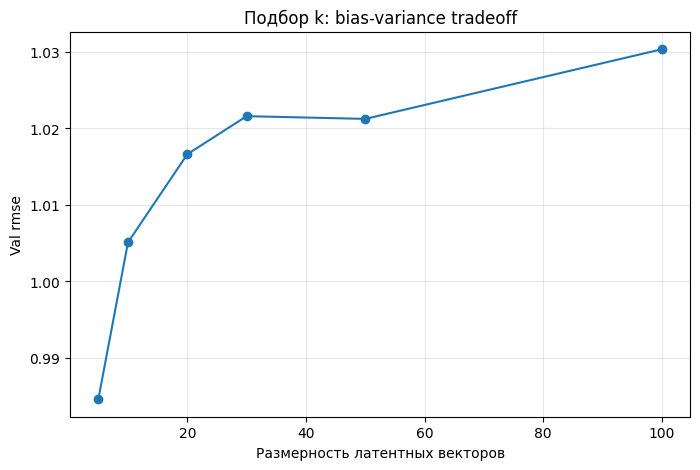


Лучший k: 5 (Val RMSE: 0.9846)


In [24]:
import matplotlib.pyplot as plt

k_values = [5, 10, 20, 30, 50, 100]
val_rmses = []

for k in k_values:
    val_rmse, _ = train_mf(k)
    val_rmses.append(val_rmse)
    print(f'k = {k:3d} | Val RMSE: {val_rmse:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(k_values, val_rmses, marker='o')
plt.xlabel('Размерность латентных векторов')
plt.ylabel('Val rmse')
plt.title('Подбор k: bias-variance tradeoff')
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_values[np.argmin(val_rmses)]
print(f'\nЛучший k: {best_k} (Val RMSE: {min(val_rmses):.4f})')

После подбора гиперпараметра k и построения график K vs RMSE, видно что наилучший k = 5, т.е. самый меньший по сетке, чем больше k тем хуже (есть небольшая просадка в 50-ти).

In [29]:
set_seed(42)
best_val_rmse, final_model = train_mf(k=5)
print(f'Финальная MF (k=5), Val RMSE: {best_val_rmse:.4f}')

final_model.eval()
test_preds = mf_predict_full(test_df)
test_rmse_mf = root_mean_squared_error(test_df['rating'].values, test_preds)
print(f'MF test RMSE (весь test, k=5): {test_rmse_mf:.4f}')

Финальная MF (k=5), Val RMSE: 0.9846
MF test RMSE (весь test, k=5): 1.1111


In [27]:
print(f'test_df размер: {len(test_df)}')
print(f'test_df период timestamp: {test_df["timestamp"].min()} - {test_df["timestamp"].max()}')
print(f'global_mean: {global_mean:.4f}')
print(test_df.head())

test_df размер: 20000
test_df период timestamp: 889237269 - 893286638
global_mean: 3.5300
       user_id  item_id  rating  timestamp
80000        3      322       3  889237269
80001        3      335       1  889237269
80002        3      323       2  889237269
80003        3      325       1  889237297
80004        3      264       2  889237297


**Ключевые наблюдения:**
- На покрытых парах MF c подобранным k (Val RMSE 0.9846) обходит лучший baseline item-mean (1.0367):
  где у юзера есть история в train, латентные факторы работают лучше константы.
- На всём тесте MF (1.1111) уступает baseline - при temporal split ~80% тестовых
  пар это cold start (новые юзеры/фильмы), где MF откатывается на global_mean.
- Разница 0.98 → 1.11 - измеренная цена cold start.
- Test RMSE выше Val RMSE, как и ожидается для честной оценки на невиданных данных.

**Методология:** validation-сет для подбора эпох и k (early stopping),
фиксированный seed для воспроизводимости, test использован один раз.
Оптимальный k=5 - малый датасет не требует высокой латентной размерности.

### Вывод
MF **решает проблему разреженности данных** - выучивает плотные векторы и работает даже для
малоактивных, но известных юзеров, побеждая baseline там, где применима. Но MF
**Не решает проблему того что в тестовых данных 85% юзеров новые**: для полностью новых юзеров/фильмов у неё нет векторов.
Это мотивирует content-based подход (рекомендации по признакам фильма без оценок)
и эксперимент с per-user split, где покрытие выше.